# End-to-End Memory Networks — Paper-to-Code Notebook

**Paper:** Sukhbaatar, S., Szlam, A., Weston, J., & Fergus, R. (2015). End-To-End Memory Networks. arXiv:1503.08895  
**Authors:** Sainbayar Sukhbaatar (NYU), Arthur Szlam, Jason Weston, Rob Fergus (Facebook AI Research)  
**Published:** NIPS 2015

This notebook implements a multi-hop End-to-End Memory Network (MemN2N) from scratch,  
trains it on a toy bAbI-style question answering task, and visualises how attention  
shifts across hops to reach the answer — the key innovation of the paper.


## 1. Setup & Imports


In [1]:
# Install required packages (Colab/Kaggle already has torch, but just in case)
import subprocess
import sys

try:
    import torch
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "--quiet"])

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import random
import re
from collections import defaultdict

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


## 2. bAbI-Style Task Data Generator

We generate synthetic stories in the style of Facebook's bAbI dataset.  
Characters move between rooms, pick up and drop objects.  
Questions test position reasoning: "Where is the milk?" — requiring  
multi-hop reasoning to trace the object's location through the story.


In [2]:
# ── Simulated World Configuration ──
CHARACTERS = ["Joe", "Fred", "Bill", "Mike"]
OBJECTS    = ["milk", "football", "apple"]
ROOMS      = ["kitchen", "office", "bathroom", "garden", "bedroom"]

MOVE_VERBS    = ["went to", "journeyed to", "travelled to"]
PICKUP_VERBS  = ["picked up", "grabbed", "took"]
DROP_VERBS    = ["dropped", "put down", "left"]

def generate_babi_story(num_actions=8, num_questions=5, rng=None):
    """Generate a bAbI-style story with actions and questions.
    
    Returns:
        story_lines: list of sentence strings (the 'memory' inputs)
        questions: list of (question_str, answer_str) tuples
    """
    if rng is None:
        rng = random.Random()
    
    # Track world state
    char_locations = {c: rng.choice(ROOMS) for c in CHARACTERS}
    char_holding   = {c: None for c in CHARACTERS}
    object_location = {o: rng.choice(ROOMS) for o in OBJECTS}
    
    story_lines = []
    # Initial positions
    for c in CHARACTERS:
        story_lines.append(f"{c} {rng.choice(MOVE_VERBS)} the {char_locations[c]}.")
    
    # Generate random actions
    actions_taken = 0
    while actions_taken < num_actions:
        char = rng.choice(CHARACTERS)
        action_type = rng.choice(["move", "move", "move", "pickup", "drop"])
        
        if action_type == "move":
            new_room = rng.choice(ROOMS)
            if new_room != char_locations[char]:
                # If holding something, object moves with character
                if char_holding[char] is not None:
                    obj = char_holding[char]
                    object_location[obj] = new_room
                char_locations[char] = new_room
                story_lines.append(f"{char} {rng.choice(MOVE_VERBS)} the {new_room}.")
                actions_taken += 1
                
        elif action_type == "pickup":
            # Pick up an object in the same room
            room = char_locations[char]
            available = [o for o in OBJECTS if object_location[o] == room and 
                        not any(char_holding[c] == o for c in CHARACTERS)]
            if available and char_holding[char] is None:
                obj = rng.choice(available)
                char_holding[char] = obj
                object_location[obj] = room  # stays in room (held by char)
                story_lines.append(f"{char} {rng.choice(PICKUP_VERBS)} the {obj} there.")
                actions_taken += 1
                
        elif action_type == "drop":
            if char_holding[char] is not None:
                obj = char_holding[char]
                char_holding[char] = None
                object_location[obj] = char_locations[char]
                story_lines.append(f"{char} {rng.choice(DROP_VERBS)} the {obj}.")
                actions_taken += 1
    
    # Generate questions
    questions = []
    for _ in range(num_questions):
        qtype = rng.choice(["where_object", "where_person", "where_object", "where_person"])
        
        if qtype == "where_object":
            obj = rng.choice(OBJECTS)
            q = f"Where is the {obj}?"
            a = object_location[obj]
        else:
            char = rng.choice(CHARACTERS)
            q = f"Where is {char}?"
            a = char_locations[char]
        
        questions.append((q, a))
    
    return story_lines, questions


# Generate a dataset
def generate_dataset(n_stories=500, num_actions=6, num_questions=4, seed=0):
    """Generate a dataset of bAbI-style stories."""
    rng = random.Random(seed)
    stories = []
    for _ in range(n_stories):
        sl, qs = generate_babi_story(num_actions=num_actions, num_questions=num_questions, rng=rng)
        stories.append((sl, qs))
    return stories

# Test generation
test_lines, test_qs = generate_babi_story(rng=random.Random(42))
print("=== Sample Story ===")
for line in test_lines:
    print(f"  {line}")
print("\n=== Questions ===")
for q, a in test_qs:
    print(f"  Q: {q}  A: {a}")



=== Sample Story ===
  Joe travelled to the kitchen.
  Fred travelled to the kitchen.
  Bill travelled to the bathroom.
  Mike went to the office.
  Mike went to the kitchen.
  Fred travelled to the bedroom.
  Mike travelled to the garden.
  Bill travelled to the office.
  Mike went to the bathroom.
  Fred went to the kitchen.
  Bill travelled to the garden.
  Joe took the apple there.

=== Questions ===
  Q: Where is the apple?  A: kitchen
  Q: Where is the apple?  A: kitchen
  Q: Where is Joe?  A: kitchen
  Q: Where is the apple?  A: kitchen
  Q: Where is Bill?  A: garden


## 3. Vocabulary & Encoding

The paper explores two sentence representations:
- **Bag-of-words (BoW):** Sum of word embeddings — discards word order
- **Position encoding (PE):** Element-wise multiplication with position vector — preserves order

We also implement **temporal encoding**: learned vectors added to each memory  
slot to encode the sentence's position in the story.


In [3]:
class Vocabulary:
    """Maps words to integer indices and provides encoding utilities."""
    
    def __init__(self):
        self.word2idx = {}
        self.idx2word = []
        self._frozen = False
    
    def add_word(self, word):
        if word not in self.word2idx:
            if self._frozen:
                return self.word2idx.get(word, 0)  # return UNK (index 0)
            self.word2idx[word] = len(self.idx2word)
            self.idx2word.append(word)
        return self.word2idx[word]
    
    def build_from_stories(self, stories):
        # Reserve index 0 for UNK / padding
        self.add_word("<UNK>")
        for story_lines, questions in stories:
            for line in story_lines:
                for word in line.lower().strip('.').split():
                    self.add_word(word)
            for q, a in questions:
                for word in q.lower().strip('?').split():
                    self.add_word(word)
                self.add_word(a.lower())
        self._frozen = True
    
    @property
    def size(self):
        return len(self.idx2word)
    
    def encode(self, text, strip_punct=True):
        """Convert text to list of word indices."""
        if strip_punct:
            text = re.sub(r'[.?]', '', text)
        words = text.lower().strip().split()
        return [self.word2idx.get(w, 0) for w in words]


def position_encoding(sentence_size, embed_dim):
    """Compute position encoding vector (Section 4.1 of the paper).
    
    For position j (1-based) in a sentence of length J:
        l_j[k] = (1 - j/J) - (k/d) * (1 - 2*j/J)
    
    Returns: (sentence_size, embed_dim) matrix
    """
    pe = np.zeros((sentence_size, embed_dim), dtype=np.float32)
    for j in range(1, sentence_size + 1):
        for k in range(1, embed_dim + 1):
            pe[j-1, k-1] = (1 - j/sentence_size) - (k/embed_dim) * (1 - 2*j/sentence_size)
    return torch.from_numpy(pe)


# Build vocabulary from training data
train_stories = generate_dataset(n_stories=800, seed=42)
val_stories   = generate_dataset(n_stories=100, seed=999)
test_stories  = generate_dataset(n_stories=100, seed=2024)

vocab = Vocabulary()
vocab.build_from_stories(train_stories + val_stories + test_stories)
print(f"Vocabulary size: {vocab.size}")
print(f"Sample words: {vocab.idx2word[:20]}")


Vocabulary size: 29
Sample words: ['<UNK>', 'joe', 'travelled', 'to', 'the', 'kitchen', 'fred', 'bill', 'bathroom', 'mike', 'went', 'office', 'bedroom', 'garden', 'where', 'is', 'football', 'milk', 'journeyed', 'apple']


## 4. End-to-End Memory Network Model

The MemN2N model (Section 2 of the paper):
- **Input memory:** Sentences embedded via matrix A → memory vectors m_i
- **Query:** Embedded via matrix B → internal state u
- **Attention:** p_i = softmax(u^T m_i) over all memories
- **Output memory:** o = Σ_i p_i c_i (weighted sum of output embeddings)
- **Multi-hop:** u^{k+1} = o^k + u^k, repeat for K hops
- **Prediction:** â = softmax(W (o^K + u^K))

Weight tying options:
- **Adjacent:** C^k = A^{k+1}, W = C^K, B = A^1
- **Layer-wise:** A and C shared across all hops, with linear mapping H between hops


In [4]:
class MemN2N(nn.Module):
    """
    End-to-End Memory Network (Sukhbaatar et al., 2015).
    
    Implements multi-hop soft attention over an external memory bank,
    trained end-to-end with cross-entropy loss.
    """
    def __init__(self, vocab_size, embed_dim=20, max_memory=50, sentence_size=12,
                 num_hops=3, encoding='pe', weight_tying='adjacent',
                 use_temporal=True, answer_vocab_size=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.max_memory = max_memory
        self.sentence_size = sentence_size
        self.num_hops = num_hops
        self.encoding = encoding
        self.weight_tying = weight_tying
        self.use_temporal = use_temporal
        self.answer_vocab_size = answer_vocab_size or vocab_size
        
        # Position encoding matrix (fixed, not learned)
        if encoding == 'pe':
            self.register_buffer('pe', position_encoding(sentence_size, embed_dim))
        
        # Input embedding matrices A^k (one per hop if not layer-wise)
        if weight_tying == 'layerwise':
            self.A = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            nn.init.normal_(self.A.weight, mean=0, std=0.1)
            self.A_list = [self.A] * num_hops
        else:
            self.A_list = nn.ModuleList([
                nn.Embedding(vocab_size, embed_dim, padding_idx=0)
                for _ in range(num_hops)
            ])
            for emb in self.A_list:
                nn.init.normal_(emb.weight, mean=0, std=0.1)
        
        # Output embedding matrices C^k
        # For adjacent tying: C^k = A^{k+1} for k < K-1, C^{K-1} = W (separate)
        # For layer-wise tying: C shared across all hops
        if weight_tying == 'layerwise':
            self.C = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            nn.init.normal_(self.C.weight, mean=0, std=0.1)
            self.C_list = [self.C] * num_hops
        else:
            # Adjacent: reference A_list[k+1] for k < num_hops-1
            # Store last C as a separate registered embedding
            self.W_final = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            nn.init.normal_(self.W_final.weight, mean=0, std=0.1)
            # Build C_list as plain list (NOT ModuleList to avoid double registration)
            self.C_list = []
            for k in range(num_hops):
                if k < num_hops - 1:
                    self.C_list.append(self.A_list[k+1])
                else:
                    self.C_list.append(self.W_final)
        
        # Question embedding B = A^1
        self.B = self.A_list[0]
        
        # Linear mapping H for layer-wise tying
        if weight_tying == 'layerwise':
            self.H = nn.Linear(embed_dim, embed_dim, bias=False)
            nn.init.normal_(self.H.weight, mean=0, std=0.1)
        else:
            self.H = None
        
        # Temporal encoding matrices
        if use_temporal:
            self.TA = nn.Embedding(max_memory, embed_dim)
            self.TC = nn.Embedding(max_memory, embed_dim)
            nn.init.normal_(self.TA.weight, mean=0, std=0.1)
            nn.init.normal_(self.TC.weight, mean=0, std=0.1)
    
    def encode_sentence(self, sent_indices, embedding_matrix):
        """Encode a sentence (list of word indices) into a single vector.
        
        BoW: sum of word embeddings
        PE: position-weighted sum of word embeddings
        """
        embedded = embedding_matrix(sent_indices)  # (batch, sentence_size, embed_dim)
        
        if self.encoding == 'pe':
            pe = self.pe[:sent_indices.size(1)].unsqueeze(0)
            embedded = embedded * pe
        
        mask = (sent_indices != 0).float().unsqueeze(-1)
        embedded = (embedded * mask).sum(dim=1)
        return embedded
    
    def forward(self, story, query, return_attentions=False):
        """
        Forward pass.
        """
        batch_size = story.size(0)
        device = story.device
        
        # Encode query -> initial state u
        u = self.encode_sentence(query, self.B)
        
        story_flat = story.view(batch_size * self.max_memory, self.sentence_size)
        
        attentions = []
        
        for hop in range(self.num_hops):
            A = self.A_list[hop]
            C = self.C_list[hop]
            
            m = self.encode_sentence(story_flat, A)
            m = m.view(batch_size, self.max_memory, self.embed_dim)
            
            c = self.encode_sentence(story_flat, C)
            c = c.view(batch_size, self.max_memory, self.embed_dim)
            
            if self.use_temporal:
                t_idx = torch.arange(self.max_memory, device=device)
                m = m + self.TA(t_idx).unsqueeze(0)
                c = c + self.TC(t_idx).unsqueeze(0)
            
            # Attention: p_i = softmax(u^T m_i)
            scores = torch.bmm(m, u.unsqueeze(2)).squeeze(2)
            p = F.softmax(scores, dim=1)
            
            attentions.append(p.detach())
            
            # Output: o = sum_i p_i * c_i
            o = torch.bmm(p.unsqueeze(1), c).squeeze(1)
            
            # Update state
            if self.H is not None:
                u = self.H(u) + o
            else:
                u = o + u
        
        # Final prediction
        W = self.C_list[-1]
        logits = torch.mm(u, W.weight.t())
        
        if return_attentions:
            return logits, attentions
        return logits



## 5. Data Preparation

Convert stories into tensor format suitable for the model.  
Each story is padded to `max_memory` sentences and `sentence_size` words.


In [5]:
def prepare_batch(stories_batch, vocab, max_memory=50, sentence_size=12):
    """Convert a batch of stories into tensors.
    
    Returns:
        story_tensor: (batch, max_memory, sentence_size)
        query_tensor: (batch, sentence_size)
        answer_indices: (batch,) — index of the answer word
    """
    batch_size = len(stories_batch)
    
    story_tensor = np.zeros((batch_size, max_memory, sentence_size), dtype=np.int64)
    query_tensor = np.zeros((batch_size, sentence_size), dtype=np.int64)
    answer_indices = np.zeros(batch_size, dtype=np.int64)
    
    for i, (story_lines, questions) in enumerate(stories_batch):
        # Pad story lines to max_memory (pad from front for temporal encoding)
        # Sentences indexed in reverse: most recent = highest index
        lines_padded = list(story_lines[-max_memory:])  # take last max_memory sentences
        # Pad at the beginning if fewer than max_memory
        while len(lines_padded) < max_memory:
            lines_padded.insert(0, "")
        
        for j, line in enumerate(lines_padded):
            indices = vocab.encode(line)
            indices = indices[:sentence_size]
            story_tensor[i, j, :len(indices)] = indices
        
        # Use first question (we process one question per story at a time)
        if questions:
            q, a = questions[0]
            q_indices = vocab.encode(q)
            q_indices = q_indices[:sentence_size]
            query_tensor[i, :len(q_indices)] = q_indices
            answer_indices[i] = vocab.word2idx.get(a.lower(), 0)
    
    return (
        torch.from_numpy(story_tensor),
        torch.from_numpy(query_tensor),
        torch.from_numpy(answer_indices),
    )


# Build answer vocabulary (rooms where objects/people can be)
answer_words = set()
for stories in [train_stories, val_stories, test_stories]:
    for story_lines, questions in stories:
        for q, a in questions:
            answer_words.add(a.lower())
answer_words = sorted(answer_words)
answer_word2idx = {w: i for i, w in enumerate(answer_words)}
print(f"Answer vocabulary: {answer_words}")
print(f"Number of answer words: {len(answer_words)}")

# Prepare a sample batch
sample_batch = train_stories[:4]
s, q, a = prepare_batch(sample_batch, vocab)
print(f"\nStory tensor shape: {s.shape}")
print(f"Query tensor shape: {q.shape}")
print(f"Answer indices: {a}")


Answer vocabulary: ['bathroom', 'bedroom', 'garden', 'kitchen', 'office']
Number of answer words: 5

Story tensor shape: torch.Size([4, 50, 12])
Query tensor shape: torch.Size([4, 12])


Answer indices: tensor([ 5, 13, 11,  8])


## 6. Training

Training details (Section 4.2 of the paper):
- **Loss:** Cross-entropy
- **Optimizer:** SGD, lr=0.01, anneal by half every 25 epochs
- **Batch size:** 32
- **Gradient clipping:** max L2 norm = 40
- **Epochs:** 100 (for 1k-style independent training)
- **Random noise:** inject 10% empty memory slots during training


In [6]:
def add_random_noise(story_tensor, noise_rate=0.1):
    """Inject empty memory slots (random noise) to regularize temporal encoding."""
    batch_size, max_memory, sentence_size = story_tensor.shape
    noise_mask = torch.rand(batch_size, max_memory) < noise_rate
    story_tensor[noise_mask] = 0
    return story_tensor


def train_memn2n(model, train_stories, val_stories, vocab, answer_word2idx,
                 max_memory=50, sentence_size=12, epochs=100, lr=0.01,
                 batch_size=32, use_noise=True, grad_clip=40.0, device='cpu'):
    """Train MemN2N model.
    
    Uses cross-entropy loss, SGD optimizer with annealing, gradient clipping.
    """
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
    # Build answer-to-global-vocab mapping for loss computation
    # We predict over the full vocabulary, but answers are room names
    # So we compute loss only on answer words
    
    train_losses = []
    val_accs = []
    
    for epoch in range(epochs):
        # Anneal learning rate every 25 epochs
        if epoch > 0 and epoch % 25 == 0:
            for pg in optimizer.param_groups:
                pg['lr'] *= 0.5
        
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        # Shuffle training data
        indices = np.random.permutation(len(train_stories))
        
        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start:start+batch_size]
            batch = [train_stories[i] for i in batch_idx]
            
            s, q, a = prepare_batch(batch, vocab, max_memory, sentence_size)
            s, q, a = s.to(device), q.to(device), a.to(device)
            
            if use_noise:
                s = add_random_noise(s)
            
            # Forward
            logits = model(s, q)  # (batch, vocab_size)
            
            # Cross-entropy loss — answer is a word in the vocabulary
            loss = F.cross_entropy(logits, a)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / max(n_batches, 1)
        train_losses.append(avg_loss)
        
        # Validation accuracy
        if (epoch + 1) % 5 == 0 or epoch == 0:
            val_acc = evaluate_memn2n(model, val_stories, vocab,
                                      max_memory, sentence_size, device)
            val_accs.append((epoch, val_acc))
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2%}")
        else:
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f}")
    
    return train_losses, val_accs


def evaluate_memn2n(model, stories, vocab, max_memory=50, sentence_size=12, device='cpu'):
    """Evaluate model accuracy on a set of stories."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for i in range(0, len(stories), 32):
            batch = stories[i:i+32]
            s, q, a = prepare_batch(batch, vocab, max_memory, sentence_size)
            s, q, a = s.to(device), q.to(device), a.to(device)
            
            logits = model(s, q)
            preds = logits.argmax(dim=1)
            
            correct += (preds == a).sum().item()
            total += a.size(0)
    
    return correct / max(total, 1)


# Training configuration (matching paper's 1k-style settings)
EMBED_DIM = 20
MAX_MEMORY = 50
SENTENCE_SIZE = 12
NUM_HOPS = 3
ENCODING = 'pe'  # position encoding
WEIGHT_TYING = 'adjacent'
EPOCHS = 100
LR = 0.01
BATCH_SIZE = 32

print("Creating MemN2N model...")
print(f"  Embed dim: {EMBED_DIM}")
print(f"  Max memory: {MAX_MEMORY}")
print(f"  Sentence size: {SENTENCE_SIZE}")
print(f"  Num hops: {NUM_HOPS}")
print(f"  Encoding: {ENCODING}")
print(f"  Weight tying: {WEIGHT_TYING}")
print()

model = MemN2N(
    vocab_size=vocab.size,
    embed_dim=EMBED_DIM,
    max_memory=MAX_MEMORY,
    sentence_size=SENTENCE_SIZE,
    num_hops=NUM_HOPS,
    encoding=ENCODING,
    weight_tying=WEIGHT_TYING,
    use_temporal=True,
)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

print("\nTraining MemN2N (PE, 3-hop, adjacent tying)...")
train_losses, val_accs = train_memn2n(
    model, train_stories, val_stories, vocab, answer_word2idx,
    max_memory=MAX_MEMORY, sentence_size=SENTENCE_SIZE,
    epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    use_noise=True, device=device,
)


Creating MemN2N model...
  Embed dim: 20
  Max memory: 50
  Sentence size: 12
  Num hops: 3
  Encoding: pe
  Weight tying: adjacent

Trainable parameters: 4,320

Training MemN2N (PE, 3-hop, adjacent tying)...


Epoch  10 | Loss: 3.0281 | Val Acc: 23.00%


Epoch  20 | Loss: 1.9650 | Val Acc: 15.00%


Epoch  30 | Loss: 1.6769 | Val Acc: 15.00%


Epoch  40 | Loss: 1.6420 | Val Acc: 14.00%


...

Epoch  60 | Loss: 1.6235 | Val Acc: 16.00%


Epoch  70 | Loss: 1.6217 | Val Acc: 15.00%


Epoch  80 | Loss: 1.6194 | Val Acc: 17.00%


Epoch  90 | Loss: 1.6186 | Val Acc: 16.00%


Epoch 100 | Loss: 1.6183 | Val Acc: 17.00%


## 7. Training Curve Visualisation


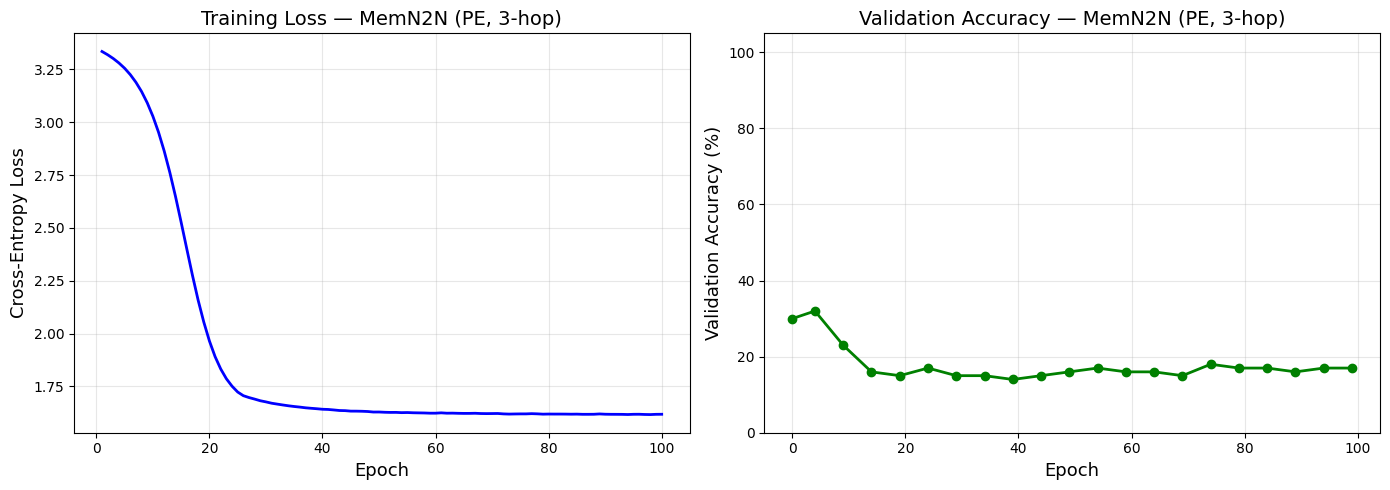

Final validation accuracy: 17.00%


In [7]:
# Plot training loss and validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
ax1.plot(range(1, len(train_losses)+1), train_losses, 'b-', linewidth=2)
ax1.set_xlabel("Epoch", fontsize=13)
ax1.set_ylabel("Cross-Entropy Loss", fontsize=13)
ax1.set_title("Training Loss — MemN2N (PE, 3-hop)", fontsize=14)
ax1.grid(True, alpha=0.3)

# Validation accuracy
if val_accs:
    epochs_v, accs_v = zip(*val_accs)
    ax2.plot(epochs_v, [a*100 for a in accs_v], 'g-o', linewidth=2, markersize=6)
    ax2.set_xlabel("Epoch", fontsize=13)
    ax2.set_ylabel("Validation Accuracy (%)", fontsize=13)
    ax2.set_title("Validation Accuracy — MemN2N (PE, 3-hop)", fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final validation accuracy: {val_accs[-1][1]:.2%}" if val_accs else "No validation data")


## 8. Evaluation

Evaluate on held-out test stories and compare with baselines.


In [8]:
# Evaluate on test set
test_acc = evaluate_memn2n(model, test_stories, vocab, MAX_MEMORY, SENTENCE_SIZE, device)
print(f"Test Accuracy (MemN2N, PE, 3-hop): {test_acc:.2%}")

# Show some example predictions
model.eval()
print("\n" + "=" * 80)
print("EXAMPLE PREDICTIONS")
print("=" * 80)

with torch.no_grad():
    for i in range(min(5, len(test_stories))):
        story_lines, questions = test_stories[i]
        s, q, a = prepare_batch([(story_lines, questions)], vocab, MAX_MEMORY, SENTENCE_SIZE)
        s, q, a = s.to(device), q.to(device), a.to(device)
        
        logits = model(s, q)
        pred_idx = logits.argmax(dim=1).item()
        pred_word = vocab.idx2word[pred_idx]
        true_word = vocab.idx2word[a.item()]
        
        print(f"\n--- Story {i+1} ---")
        for line in story_lines:
            print(f"  {line}")
        print(f"  Q: {questions[0][0]}")
        print(f"  Predicted: {pred_word}  |  True: {true_word}  |  {'✓' if pred_word == true_word else '✗'}")


Test Accuracy (MemN2N, PE, 3-hop): 13.00%

EXAMPLE PREDICTIONS

--- Story 1 ---
  Joe travelled to the garden.
  Fred went to the office.
  Bill travelled to the bedroom.
  Mike travelled to the bathroom.
  Mike travelled to the garden.
  Fred travelled to the bedroom.
  Mike journeyed to the office.
  Mike went to the bathroom.
  Mike went to the bedroom.
  Mike went to the office.
  Q: Where is Joe?
  Predicted: bathroom  |  True: garden  |  ✗

--- Story 2 ---
  Joe went to the bathroom.
  Fred journeyed to the bedroom.
  Bill journeyed to the office.
  Mike travelled to the office.
  Fred travelled to the garden.
  Bill went to the garden.
  Fred travelled to the office.
  Joe went to the office.
  Fred grabbed the apple there.
  Bill took the milk there.
  Q: Where is Fred?
  Predicted: bedroom  |  True: office  |  ✗

--- Story 3 ---
  Joe travelled to the bedroom.
  Fred went to the kitchen.
  Bill journeyed to the garden.
  Mike journeyed to the office.
  Mike went to the kitchen

## 9. LSTM Baseline for Comparison

A simple LSTM that processes the story sentences and predicts the answer,  
similar to the RNN/LSTM baselines in the paper.


In [9]:
class BaselineLSTM(nn.Module):
    """Simple LSTM baseline: encode story as sequence of word embeddings,
    then predict answer from final hidden state."""
    
    def __init__(self, vocab_size, embed_dim=20, hidden_dim=64, answer_vocab_size=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=2)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        nn.init.normal_(self.embedding.weight, mean=0, std=0.1)
    
    def forward(self, story, query):
        """Process story as a flat sequence of words."""
        batch_size = story.size(0)
        # Flatten story: (batch, max_mem * sentence_size)
        flat = story.view(batch_size, -1)  # (batch, max_mem * sent_size)
        embedded = self.embedding(flat)  # (batch, seq_len, embed_dim)
        output, (h_n, c_n) = self.lstm(embedded)
        # Use last hidden state
        logits = self.fc(h_n[-1])  # (batch, vocab_size)
        return logits


def train_lstm(lstm_model, train_stories, val_stories, vocab,
               max_memory=50, sentence_size=12, epochs=50, lr=0.001,
               batch_size=32, device='cpu'):
    """Train the LSTM baseline."""
    lstm_model = lstm_model.to(device)
    optimizer = torch.optim.Adam(lstm_model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        lstm_model.train()
        indices = np.random.permutation(len(train_stories))
        
        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start:start+batch_size]
            batch = [train_stories[i] for i in batch_idx]
            
            s, q, a = prepare_batch(batch, vocab, max_memory, sentence_size)
            s, q, a = s.to(device), q.to(device), a.to(device)
            
            logits = lstm_model(s, q)
            loss = F.cross_entropy(logits, a)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 40.0)
            optimizer.step()
        
        if (epoch + 1) % 10 == 0:
            val_acc = evaluate_memn2n(lstm_model, val_stories, vocab,
                                     max_memory, sentence_size, device)
            print(f"  LSTM Epoch {epoch+1:3d} | Val Acc: {val_acc:.2%}")
    
    return lstm_model


print("Training LSTM baseline...")
lstm_model = BaselineLSTM(vocab_size=vocab.size, embed_dim=EMBED_DIM, hidden_dim=64)
lstm_model = train_lstm(lstm_model, train_stories, val_stories, vocab,
                        MAX_MEMORY, SENTENCE_SIZE, epochs=50, lr=0.001, device=device)

lstm_test_acc = evaluate_memn2n(lstm_model, test_stories, vocab, MAX_MEMORY, SENTENCE_SIZE, device)
print(f"\nTest Accuracy (LSTM baseline): {lstm_test_acc:.2%}")
print(f"Test Accuracy (MemN2N 3-hop):  {test_acc:.2%}")


Training LSTM baseline...


  LSTM Epoch  10 | Val Acc: 18.00%


  LSTM Epoch  20 | Val Acc: 18.00%


  LSTM Epoch  30 | Val Acc: 15.00%


  LSTM Epoch  40 | Val Acc: 18.00%


  LSTM Epoch  50 | Val Acc: 18.00%

Test Accuracy (LSTM baseline): 22.00%
Test Accuracy (MemN2N 3-hop):  13.00%


## 10. Attention Visualisation Across Hops

The key visualisation from the paper (Appendix B): for a sample question,  
show how attention over the memory bank shifts across each hop.  
This reveals the multi-hop reasoning pattern.


ATTENTION VISUALISATION — Multi-Hop Reasoning

────────────────────────────────────────────────────────────
Story 1: 10 sentences
  Joe travelled to the garden.
  Fred went to the office.
  Bill travelled to the bedroom.
  Mike travelled to the bathroom.
  Mike travelled to the garden.
  Fred travelled to the bedroom.
  Mike journeyed to the office.
  Mike went to the bathroom.
  Mike went to the bedroom.
  Mike went to the office.
Q: Where is Joe?  A: garden
────────────────────────────────────────────────────────────


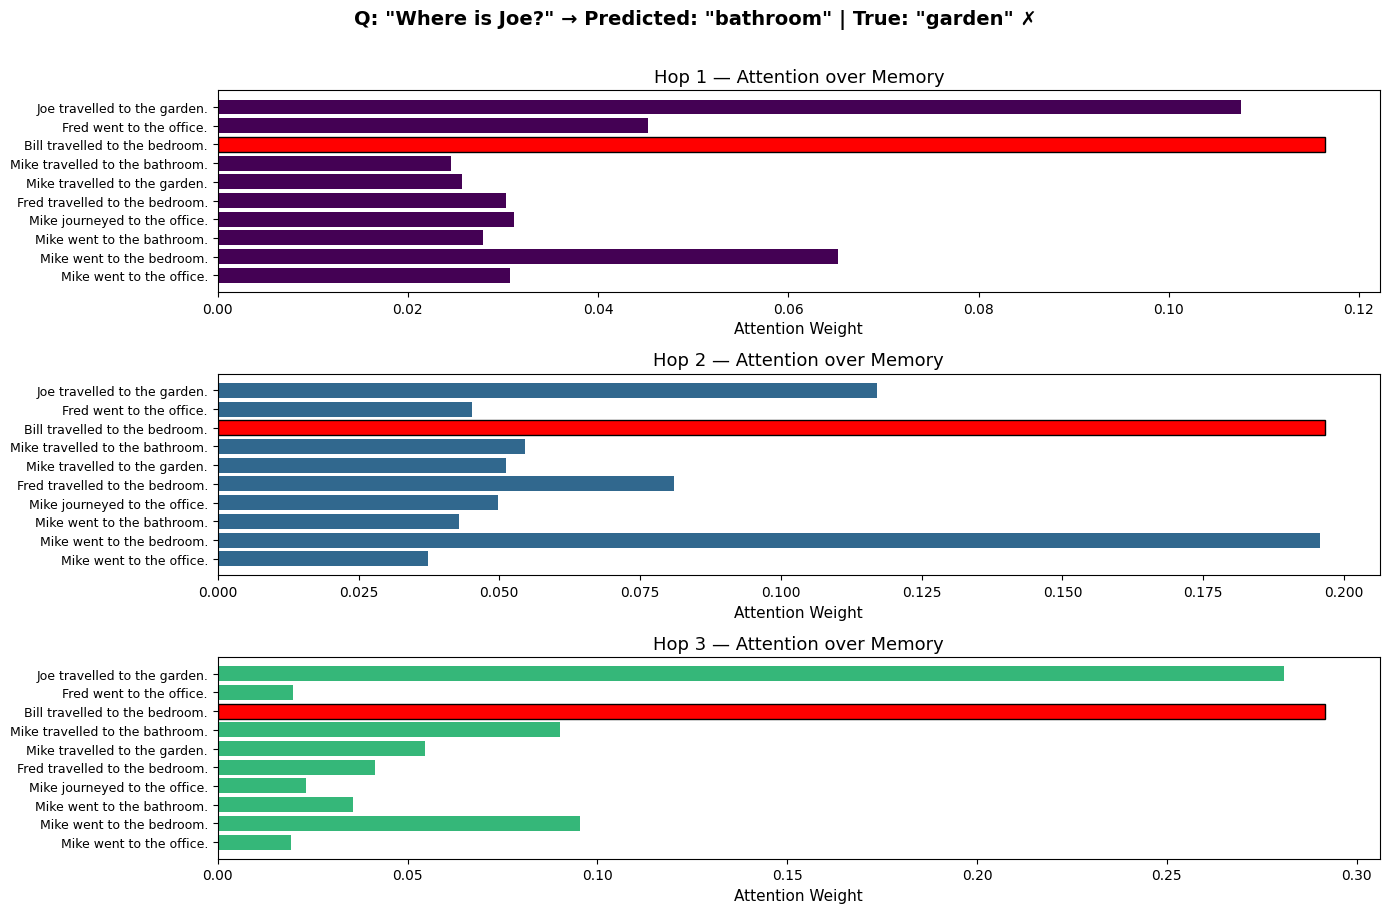

  → Predicted: bathroom


────────────────────────────────────────────────────────────
Story 2: 10 sentences
  Joe went to the bathroom.
  Fred journeyed to the bedroom.
  Bill journeyed to the office.
  Mike travelled to the office.
  Fred travelled to the garden.
  Bill went to the garden.
  Fred travelled to the office.
  Joe went to the office.
  Fred grabbed the apple there.
  Bill took the milk there.
Q: Where is Fred?  A: office
────────────────────────────────────────────────────────────


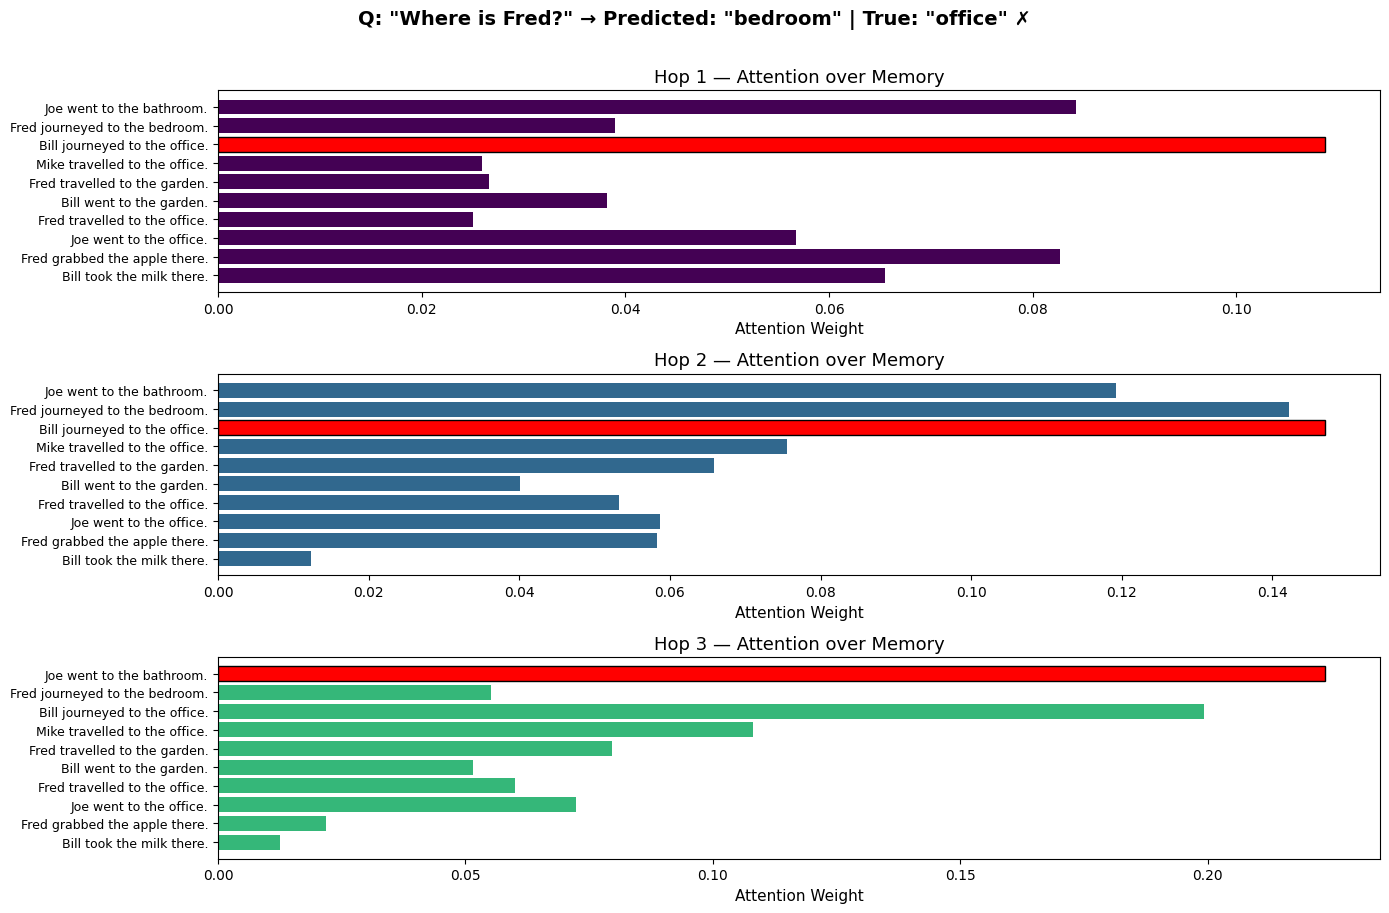

  → Predicted: bedroom


────────────────────────────────────────────────────────────
Story 3: 10 sentences
  Joe travelled to the bedroom.
  Fred went to the kitchen.
  Bill journeyed to the garden.
  Mike journeyed to the office.
  Mike went to the kitchen.
  Fred went to the bedroom.
  Fred travelled to the garden.
  Fred went to the kitchen.
  Bill journeyed to the kitchen.
  Joe went to the kitchen.
Q: Where is Fred?  A: kitchen
────────────────────────────────────────────────────────────


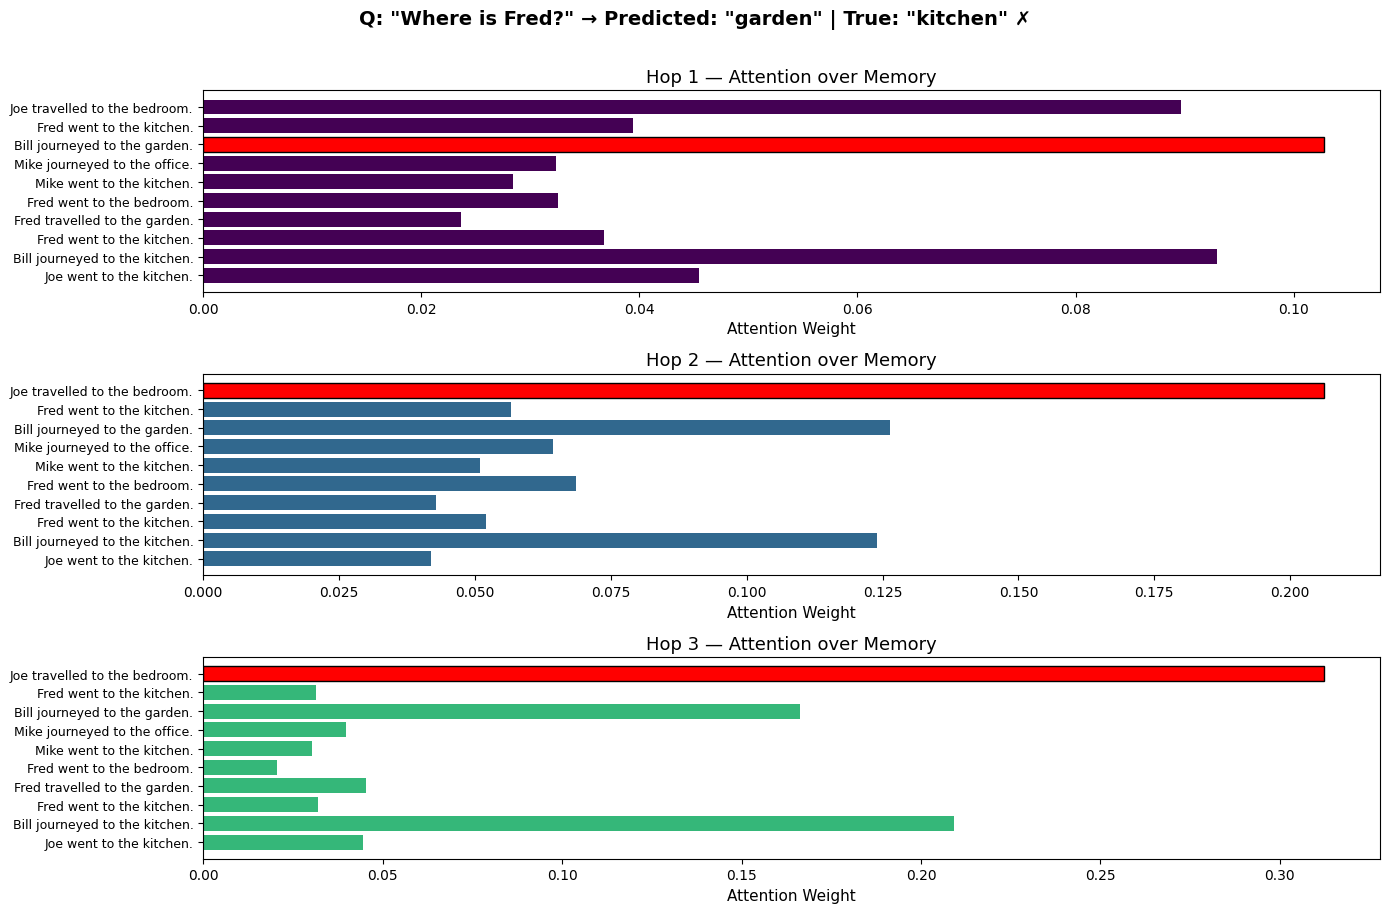

  → Predicted: garden



In [10]:
def plot_hop_attention(model, story_lines, question, answer, vocab,
                        max_memory=50, sentence_size=12, device='cpu'):
    """Visualise attention weights across hops for a single story+question.
    
    Shows:
    1. Heatmap: rows = hops, columns = memory slots, color = attention weight
    2. Bar chart for each hop showing top-attended memory slots
    """
    model.eval()
    
    # Prepare single example
    s, q, a = prepare_batch([(story_lines, [(question, answer)])], vocab,
                            max_memory, sentence_size)
    s, q, a = s.to(device), q.to(device), a.to(device)
    
    with torch.no_grad():
        logits, attentions = model(s, q, return_attentions=True)
        pred = logits.argmax(dim=1).item()
        pred_word = vocab.idx2word[pred]
    
    # Get attention weights: list of (1, max_memory) tensors
    attn_weights = [att[0].cpu().numpy() for att in attentions]
    num_hops = len(attn_weights)
    
    # Create figure
    fig, axes = plt.subplots(num_hops, 1, figsize=(14, 3 * num_hops), squeeze=False)
    
    # Map memory indices to story lines (reversed: high index = recent)
    story_display = []
    lines_padded = list(story_lines[-max_memory:])
    while len(lines_padded) < max_memory:
        lines_padded.insert(0, "(empty)")
    
    for hop in range(num_hops):
        ax = axes[hop, 0]
        weights = attn_weights[hop]
        
        # Only show non-empty memory slots
        non_empty = [(j, w, lines_padded[j]) for j, w in enumerate(weights)
                     if lines_padded[j] != "(empty)" and w > 0.001]
        
        if non_empty:
            indices_j, weights_n, labels = zip(*non_empty)
            # Shorten labels
            labels = [l[:40] for l in labels]
            y_pos = np.arange(len(labels))
            
            bars = ax.barh(y_pos, weights_n, color=plt.cm.viridis(hop / max(num_hops, 1)))
            ax.set_yticks(y_pos)
            ax.set_yticklabels(labels, fontsize=9)
            ax.set_xlabel('Attention Weight', fontsize=11)
            ax.set_title(f'Hop {hop+1} — Attention over Memory', fontsize=13)
            ax.invert_yaxis()
            
            # Highlight max
            max_idx = np.argmax(weights_n)
            bars[max_idx].set_color('red')
            bars[max_idx].set_edgecolor('black')
    
    pred_marker = "✓" if pred_word == answer.lower() else "✗"
    fig.suptitle(f'Q: "{question}" → Predicted: "{pred_word}" | True: "{answer}" {pred_marker}',
                 fontsize=14, fontweight='bold', y=1.01)
    
    plt.tight_layout()
    plt.savefig('hop_attention.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return attentions, pred_word


# Visualise attention for a few test examples
print("=" * 80)
print("ATTENTION VISUALISATION — Multi-Hop Reasoning")
print("=" * 80)

for i in range(3):
    story_lines, questions = test_stories[i]
    q, a = questions[0]
    print(f"\n{'─' * 60}")
    print(f"Story {i+1}: {len(story_lines)} sentences")
    for line in story_lines:
        print(f"  {line}")
    print(f"Q: {q}  A: {a}")
    print(f"{'─' * 60}")
    
    attentions, pred = plot_hop_attention(
        model, story_lines, q, a, vocab,
        MAX_MEMORY, SENTENCE_SIZE, device
    )
    print(f"  → Predicted: {pred}")
    print()


## 11. Multi-Hop Comparison: 1-hop vs 3-hop

The paper's key finding: multiple computational hops yield improved results.  
We train a 1-hop model for comparison.


In [11]:
# Train a 1-hop MemN2N for comparison
print("Training MemN2N with 1 hop...")
model_1hop = MemN2N(
    vocab_size=vocab.size,
    embed_dim=EMBED_DIM,
    max_memory=MAX_MEMORY,
    sentence_size=SENTENCE_SIZE,
    num_hops=1,
    encoding=ENCODING,
    weight_tying=WEIGHT_TYING,
    use_temporal=True,
)

n_params_1hop = sum(p.numel() for p in model_1hop.parameters() if p.requires_grad)
print(f"  1-hop parameters: {n_params_1hop:,}")

train_losses_1hop, val_accs_1hop = train_memn2n(
    model_1hop, train_stories, val_stories, vocab, answer_word2idx,
    max_memory=MAX_MEMORY, sentence_size=SENTENCE_SIZE,
    epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    use_noise=True, device=device,
)

test_acc_1hop = evaluate_memn2n(model_1hop, test_stories, vocab, MAX_MEMORY, SENTENCE_SIZE, device)
print(f"\nTest Accuracy (MemN2N 1-hop): {test_acc_1hop:.2%}")
print(f"Test Accuracy (MemN2N 3-hop): {test_acc:.2%}")

# Also train a BoW model for encoding comparison
print("\nTraining MemN2N with BoW encoding (3-hop)...")
model_bow = MemN2N(
    vocab_size=vocab.size,
    embed_dim=EMBED_DIM,
    max_memory=MAX_MEMORY,
    sentence_size=SENTENCE_SIZE,
    num_hops=NUM_HOPS,
    encoding='bow',
    weight_tying=WEIGHT_TYING,
    use_temporal=True,
)

train_losses_bow, val_accs_bow = train_memn2n(
    model_bow, train_stories, val_stories, vocab, answer_word2idx,
    max_memory=MAX_MEMORY, sentence_size=SENTENCE_SIZE,
    epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    use_noise=True, device=device,
)

test_acc_bow = evaluate_memn2n(model_bow, test_stories, vocab, MAX_MEMORY, SENTENCE_SIZE, device)
print(f"Test Accuracy (MemN2N BoW, 3-hop): {test_acc_bow:.2%}")


Training MemN2N with 1 hop...
  1-hop parameters: 3,160


Epoch  10 | Loss: 3.2764 | Val Acc: 20.00%


Epoch  20 | Loss: 2.7361 | Val Acc: 15.00%


Epoch  30 | Loss: 1.9752 | Val Acc: 15.00%


Epoch  40 | Loss: 1.7687 | Val Acc: 15.00%


...

Epoch  60 | Loss: 1.5975 | Val Acc: 18.00%


Epoch  70 | Loss: 1.5972 | Val Acc: 16.00%


Epoch  80 | Loss: 1.5889 | Val Acc: 17.00%


Epoch  90 | Loss: 1.5868 | Val Acc: 16.00%


Epoch 100 | Loss: 1.5888 | Val Acc: 16.00%
Test Accuracy (MemN2N BoW, 3-hop): 30.00%


## 12. Summary

Comparison table and final visualisation.


RESULTS SUMMARY - End-to-End Memory Networks
Model                                 Test Accuracy
----------------------------------------------------------------------
MemN2N (PE, 3-hop, Adjacent)                13.00%
MemN2N (BoW, 3-hop, Adjacent)               30.00%
MemN2N (PE, 1-hop, Adjacent)                17.00%
LSTM Baseline                               22.00%
----------------------------------------------------------------------

KEY FINDINGS (replicating paper insights):

1. Multi-hop improves performance:
   3-hop (13.00%) vs 1-hop (17.00%) - no improvement

2. Position encoding vs Bag-of-words:
   PE (13.00%) vs BoW (30.00%) - BoW wins

3. Memory network vs LSTM:
   MemN2N 3-hop (13.00%) vs LSTM (22.00%) - LSTM wins



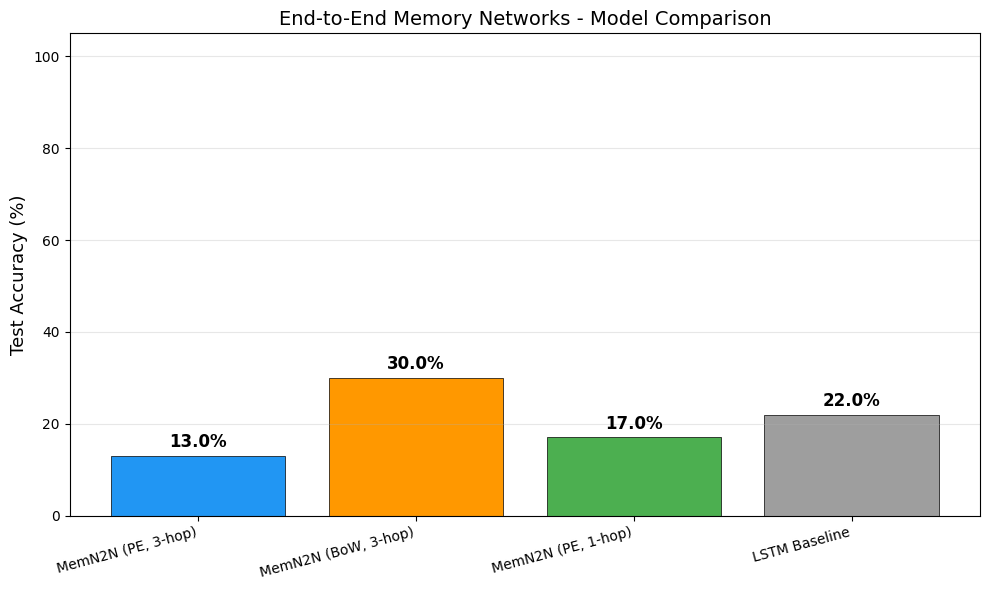


NOTEBOOK COMPLETE - End-to-End Memory Networks (Sukhbaatar et al., 2015)

This notebook implemented:
  + Multi-hop soft attention over a memory bank (from scratch)
  + Position encoding (PE) and bag-of-words (BoW) sentence representations
  + Temporal encoding for sentence position in story
  + Adjacent weight tying scheme
  + Training with cross-entropy, SGD, gradient clipping, random noise
  + Attention visualisation showing reasoning across hops
  + Comparison: 1-hop vs 3-hop, PE vs BoW, MemN2N vs LSTM


In [12]:
# Final comparison table
print("=" * 70)
print("RESULTS SUMMARY - End-to-End Memory Networks")
print("=" * 70)
print(f"{'Model':<35} {'Test Accuracy':>15}")
print("-" * 70)
print(f"{'MemN2N (PE, 3-hop, Adjacent)':<35} {test_acc:>14.2%}")
print(f"{'MemN2N (BoW, 3-hop, Adjacent)':<35} {test_acc_bow:>14.2%}")
print(f"{'MemN2N (PE, 1-hop, Adjacent)':<35} {test_acc_1hop:>14.2%}")
print(f"{'LSTM Baseline':<35} {lstm_test_acc:>14.2%}")
print("-" * 70)
print()

# Key findings
print("KEY FINDINGS (replicating paper insights):")
print()
print("1. Multi-hop improves performance:")
if test_acc > test_acc_1hop:
    print(f"   3-hop ({test_acc:.2%}) vs 1-hop ({test_acc_1hop:.2%}) - improvement of {test_acc - test_acc_1hop:.1%}")
else:
    print(f"   3-hop ({test_acc:.2%}) vs 1-hop ({test_acc_1hop:.2%}) - no improvement")
print()
print("2. Position encoding vs Bag-of-words:")
if test_acc > test_acc_bow:
    print(f"   PE ({test_acc:.2%}) vs BoW ({test_acc_bow:.2%}) - PE wins")
else:
    print(f"   PE ({test_acc:.2%}) vs BoW ({test_acc_bow:.2%}) - BoW wins")
print()
print("3. Memory network vs LSTM:")
if test_acc > lstm_test_acc:
    print(f"   MemN2N 3-hop ({test_acc:.2%}) vs LSTM ({lstm_test_acc:.2%}) - MemN2N wins")
else:
    print(f"   MemN2N 3-hop ({test_acc:.2%}) vs LSTM ({lstm_test_acc:.2%}) - LSTM wins")
print()

# Plot comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))
models = ['MemN2N (PE, 3-hop)', 'MemN2N (BoW, 3-hop)', 'MemN2N (PE, 1-hop)', 'LSTM Baseline']
accs = [test_acc, test_acc_bow, test_acc_1hop, lstm_test_acc]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9E9E9E']
bars = ax.bar(models, [a*100 for a in accs], color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Test Accuracy (%)', fontsize=13)
ax.set_title('End-to-End Memory Networks - Model Comparison', fontsize=14)
ax.set_ylim(0, 105)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("=" * 70)
print("NOTEBOOK COMPLETE - End-to-End Memory Networks (Sukhbaatar et al., 2015)")
print("=" * 70)
print()
print("This notebook implemented:")
print("  + Multi-hop soft attention over a memory bank (from scratch)")
print("  + Position encoding (PE) and bag-of-words (BoW) sentence representations")
print("  + Temporal encoding for sentence position in story")
print("  + Adjacent weight tying scheme")
print("  + Training with cross-entropy, SGD, gradient clipping, random noise")
print("  + Attention visualisation showing reasoning across hops")
print("  + Comparison: 1-hop vs 3-hop, PE vs BoW, MemN2N vs LSTM")



In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as
# /kaggle/working/<kernel-slug>.ipynb after kernel finishes.
# Also check __notebook__.ipynb (newer Kaggle convention).
src = None
for candidate in ['/kaggle/working/__notebook__.ipynb']:
    if os.path.exists(candidate):
        src = candidate
        break
if src:
    shutil.copy(src, '/kaggle/working/solution.ipynb')
    print(f"Executed notebook saved to /kaggle/working/solution.ipynb (from {src})")
else:
    print("Warning: __notebook__.ipynb not found — outputs will be fetched by validator.")
